In [1]:
#Import dependencies
import os
import pandas as pd
import numpy as np
import numpy_financial as npf
import seaborn as sns
from scripts.gep_script import *
pd.options.mode.chained_assignment = None
import matplotlib.pyplot as plt
%matplotlib inline



## Data exploration

Descriptive statistics

In [2]:
path=os.getcwd()+ '/results/scenarios'

for scenario_file in sorted(os.listdir(path)):
    
    if scenario_file.endswith(".csv"):
        
        scenario = scenario_file.split('.')[0]
        
        file = path + f'/{scenario_file}'
        df = pd.read_csv(file)
        
        if scenario == 'ng-3-0_0_0_0_1_0-results':
            scenario = 'BSCU'
        elif scenario == 'ng-3-0_0_0_1_1_0-results':
            scenario = 'BSCU-L'
        elif scenario == 'ng-3-0_1_0_0_1_0-results':
            scenario = 'Baseline'
        elif scenario == 'ng-3-0_1_0_1_1_0-results':
            scenario = 'Baseline-L'
        elif scenario == 'ng-3-2_0_0_0_1_0-results':
            scenario = 'HDSCU'
        elif scenario == 'ng-3-2_0_0_1_1_0-results':
            scenario = 'HDSCU-L'
        
        print(scenario)
        
        
        print(df[["Ft_PerTonRes","MinimumOverallGenLCOE2030","TotalEnergyPerCell"]].describe())
        print(f'{df[["MinimumOverall2030"]].value_counts()} \n')
        

BSCU
       Ft_PerTonRes  MinimumOverallGenLCOE2030  TotalEnergyPerCell
count     72.000000                  72.000000           72.000000
mean      10.723841                   0.258707        32917.515236
std      133.987632                   0.008170        36710.037479
min     -553.273599                   0.241618         5772.549000
25%     -112.836631                   0.252769        10185.142500
50%      106.261704                   0.258288        19128.033000
75%      127.943350                   0.262601        41019.051000
max      208.326315                   0.283328       210449.660000
MinimumOverall2030
MG_PV_Hybrid2030      72
dtype: int64 

BSCU-L
       Ft_PerTonRes MinimumOverallGenLCOE2030 TotalEnergyPerCell
count             0                         0                  0
unique            0                         0                  0
top             NaN                       NaN                NaN
freq            NaN                       NaN                NaN
S

## Plotting the Delivered Feedstock Price vs LCOE 

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
/var/folders/cy/jdfsbm4x3194_qj1bgwsjp6c0000gn/T/ipykernel_60684/4170922250.py:22: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='MinimumOverallGenLCOE2030',y='Ft_PerTonRes',  hue = 'Tier', ax = axis[1, 1],data=df, palette=palette)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


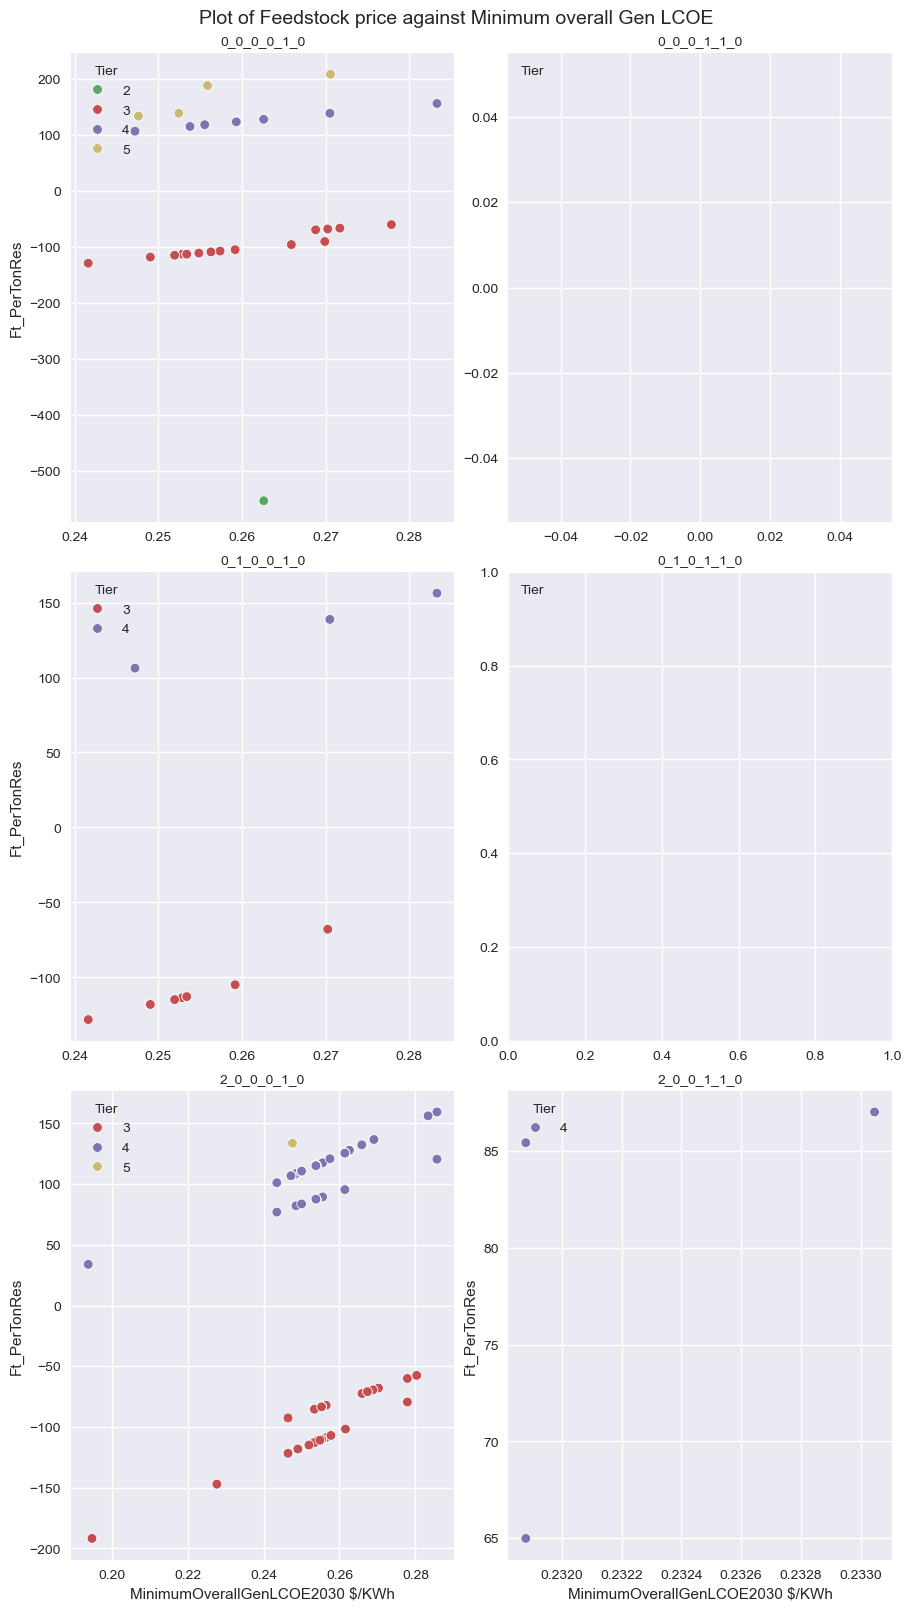

In [3]:
plt.style.use('seaborn')
figure, axis = plt.subplots(3, 2, figsize=(9,16),layout='constrained')
count = 0

palette ={1: "k", 2: "C1", 3: "C2", 4: "C3", 5: "C4"}

for scenario_file in sorted(os.listdir(path)):
    
    if scenario_file.endswith(".csv"):
        
        scenario = scenario_file.split('.')[0]
        file = path + f'/{scenario_file}'
        df = pd.read_csv(file)
        
        if count%2 == 0:
            sns.scatterplot(x='MinimumOverallGenLCOE2030',y='Ft_PerTonRes', hue = 'Tier', ax = axis[count//2,0], data=df, palette=palette)
            axis[count//2,0].set_title(scenario.split('-')[2], fontsize=10)
            axis[count//2,0].legend(title='Tier',loc='upper left')
            axis[count//2,0].set(xlabel=None)
        
        elif count == 3:
            sns.scatterplot(x='MinimumOverallGenLCOE2030',y='Ft_PerTonRes',  hue = 'Tier', ax = axis[1, 1],data=df, palette=palette)
            axis[1, 1].set_title(scenario.split('-')[2], fontsize=10)
            axis[1, 1].legend(title='Tier',loc='upper left')
            axis[1, 1].set(xlabel=None)
            
        elif count == 5:
            sns.scatterplot(x='MinimumOverallGenLCOE2030',y='Ft_PerTonRes', hue = 'Tier', ax = axis[2, 1], data=df, palette=palette)
            axis[2, 1].set_title(scenario.split('-')[2], fontsize=10)
            axis[2, 1].legend(title='Tier',loc='upper left')
            axis[2, 1].set(xlabel=None)
            
        else:
            sns.scatterplot(x='MinimumOverallGenLCOE2030',y='Ft_PerTonRes', ax = axis[(count%2)-1, 1], data=df)
            axis[(count%2)-1, 1].set_title(scenario.split('-')[2], fontsize=10)
            axis[(count%2)-1, 1].legend(title='Tier',loc='upper left')
            axis[(count%2)-1, 1].set(xlabel=None)
            
        count+=1
    
figure.suptitle('Plot of Feedstock price against Minimum overall Gen LCOE', fontsize=14)
plt.setp(axis[-1, :], xlabel='MinimumOverallGenLCOE2030 $/KWh')
plt.setp(axis[:, 0], ylabel='Ft_PerTonRes')
plt.show()

## Combining all scenarios into one file


In [4]:
path=os.getcwd()+ '/results/scenarios'
resultPath = os.getcwd()+ '/results'
df = pd.DataFrame()

for scenario_file in sorted(os.listdir(path)):
    
    if scenario_file.endswith(".csv"):
        
        scenario = scenario_file.split('.')[0]
        
        file = path + f'/{scenario_file}'
        data = pd.read_csv(file)
        
        data['scenario'] = [scenario.split('-')[2] for i in data['Ft_PerTonRes']]
        
        df = pd.concat([df, data], axis=0)

df.to_csv(resultPath + '/combined-scenario-results.csv', index=False)


## Analysing duplicates across scenarios using ID's

In [5]:
file=os.getcwd()+ '/results/combined-scenario-results.csv'
df = pd.read_csv(file)

df[['Tier', 'MinimumOverallGenLCOE2030', 'Generation_Capex2030', 'MinimumOverall2030', 'Ft_PerTonRes', 'scenario']]

,Tier,MinimumOverallGenLCOE2030,Generation_Capex2030,MinimumOverall2030,Ft_PerTonRes,scenario
0,3,0.254848,67117.195,MG_PV_Hybrid2030,-110.858586,0_0_0_0_1_0
1,3,0.254848,54139.660,MG_PV_Hybrid2030,-110.858586,0_0_0_0_1_0
2,3,0.259190,99909.130,MG_PV_Hybrid2030,-104.924451,0_0_0_0_1_0
3,3,0.249045,268959.880,MG_PV_Hybrid2030,-118.063900,0_0_0_0_1_0
4,4,0.262599,22063.293,MG_PV_Hybrid2030,127.943350,0_0_0_0_1_0
...,...,...,...,...,...,...
1641,4,0.253792,18451.870,MG_PV_Hybrid2030,87.637089,2_0_0_0_1_0
1642,4,0.231878,21914.166,MG_PV_Hybrid2030,85.434705,2_0_0_1_1_0
1643,4,0.231878,31225.928,MG_PV_Hybrid2030,85.434705,2_0_0_1_1_0
1644,4,0.233047,19496.896,MG_PV_Hybrid2030,87.021728,2_0_0_1_1_0


In [6]:
ids = df['id']

# Check and extract duplicate
dp_df = df[ids.isin(ids[ids.duplicated()])].sort_values("id")

# Counting duplicates
duplicates = dp_df.pivot_table(index = ['id'], aggfunc ='size')
duplicates

unique_dp = dp_df.drop_duplicates(subset=['id'])
unique_dp['idCount'] = duplicates.values

dp_df

,GridCellArea,X_deg,Y_deg,id,Admin1,Pop2030,TotalEnergyPerCell,Tier,Generation_Capex2025,WindHybridGenLCOE2030,...,CapFactor,GasifierCap,investment,NpvIt,NpvGen,NpvOM,NpvRes,NpvFt,Ft_PerTonRes,scenario
53,0.061,5.863,10.440,32405,Niger,175.200,64880.2030,4,0.00,0.931978,...,0.666667,37.032079,83211.082272,77767.366610,7.560868e+05,48485.363431,553.234275,59148.277225,106.913617,0_0_0_0_1_0
80,0.061,5.863,10.440,32405,Niger,175.200,42896.0040,3,0.00,0.966145,...,0.333333,48.968041,110031.188342,102832.886301,4.998922e+05,64112.880278,365.774744,-41535.723204,-113.555471,0_1_0_0_1_0
1306,0.009,12.100,13.090,81578,Yobe,15.914,17868.7250,5,0.00,0.350146,...,0.958333,7.094987,15942.436004,14899.472901,2.082347e+05,9289.325202,201.517426,26958.385356,133.776944,2_0_0_0_1_0
48,0.009,12.100,13.090,81578,Yobe,15.914,14732.8540,5,0.00,0.350146,...,0.958333,5.849853,13144.618995,12284.690649,1.716905e+05,7659.095540,166.152135,22227.324867,133.776944,0_0_0_0_1_0
7,0.052,14.250,11.910,211583,Borno,481.200,120592.4200,3,0.00,0.966145,...,0.333333,137.662580,309327.817055,289091.417808,1.405334e+06,180238.872270,1034.601568,-122149.096244,-118.063900,0_0_0_0_1_0
470,0.052,14.250,11.910,211583,Borno,481.200,135914.0300,4,196170.78,0.931978,...,0.666667,77.576501,174314.398065,162910.652397,1.583885e+06,101569.366851,1166.050641,134329.461004,115.200366,2_0_0_0_1_0
6,0.060,13.860,12.016,221054,Borno,414.800,149672.3300,4,0.00,0.442826,...,0.666667,85.429412,191959.888990,179401.765411,1.744219e+06,111851.026662,1284.087568,147927.358317,115.200366,0_0_0_0_1_0
453,0.060,13.860,12.016,221054,Borno,414.800,120053.3900,4,173278.42,0.442826,...,0.666667,68.523624,153972.584092,143899.611301,1.399052e+06,89716.615795,1029.977055,118653.734058,115.200366,2_0_0_0_1_0
74,0.060,13.860,12.016,221054,Borno,414.800,96562.7900,3,0.00,0.484020,...,0.333333,110.231495,247690.170240,231486.140411,1.125303e+06,144323.900066,828.443562,-97809.277974,-118.063900,0_1_0_0_1_0
1598,0.035,13.360,12.380,236114,Borno,445.500,125866.0800,4,181668.14,0.442826,...,0.666667,71.841370,161427.558082,150866.876712,1.466791e+06,94060.473769,1079.846012,124398.656158,115.200366,2_0_0_0_1_0


In [7]:
# Dropping duplicate id's

df_dropped = df[~df['id'].isin(duplicates.index)]
df_dropped.to_csv(resultPath + '/non-duplicates.csv', index=False)

In [8]:
## Write to file duplicate zones
dp_df.to_csv(resultPath + '/duplicates.csv', index=False) # contains duplicates

In [9]:
# unique_dp[(unique_dp.idCount >1)]
unique_dp_scenarios = dp_df.groupby('id')['scenario'].unique()

## Adding the scenarios to duplicate ids
# unique_dp['scenario']= [','.join(arr) for arr in unique_dp_scenarios]

## Adding residue prices Ft_PerTonRes
unique_dp_prices = dp_df.groupby('id')['Ft_PerTonRes'].unique()

# duplicates[(duplicates.values > 3)],
unique_dp_scenarios



unique_dp_df = unique_dp_prices.to_frame()
unique_dp_df['idCount'] = duplicates.values
unique_dp_df

,Ft_PerTonRes,idCount
id,,
32405,"[106.91361673555332, -113.5554705288932]",2
81578,[133.7769440107824],2
211583,"[-118.0639001232292, 115.20036635505204]",2
221054,"[115.20036635505204, -118.0639001232291]",3
236114,"[115.20036635505204, 115.20036635505208, -118....",3
247622,"[85.43470543838532, 115.20036635505198]",2
314845,"[106.26170443838537, 106.26170443838542]",2
363099,"[-114.81467619555976, -114.81467619555978]",2
364701,"[-112.83663119556002, -112.83663119555986]",2


In [10]:
maxFtPerTonRes = []
posFtCount = []

for i, val in enumerate(unique_dp_prices):
    ftCount = 0
    
    maxFtPerTonRes.append(max(val))
    
    for value in val:
        if value >= 0:
            ftCount+=1

    posFtCount.append(ftCount)        

unique_dp['maxFtPerTonRes'] = maxFtPerTonRes
unique_dp['posFtCount'] = posFtCount
unique_dp['Ft_PerTonRes'] = unique_dp_prices.values


In [11]:
# unique duplicates with count number and max feedstock price

unique_dp.drop('scenario', axis=1, inplace=True)

unique_dp


,GridCellArea,X_deg,Y_deg,id,Admin1,Pop2030,TotalEnergyPerCell,Tier,Generation_Capex2025,WindHybridGenLCOE2030,...,investment,NpvIt,NpvGen,NpvOM,NpvRes,NpvFt,Ft_PerTonRes,idCount,maxFtPerTonRes,posFtCount
53,0.061,5.863,10.440,32405,Niger,175.200,64880.2030,4,0.00,0.931978,...,83211.082272,77767.366610,7.560868e+05,48485.363431,553.234275,59148.277225,"[106.91361673555332, -113.5554705288932]",2,106.913617,1
1306,0.009,12.100,13.090,81578,Yobe,15.914,17868.7250,5,0.00,0.350146,...,15942.436004,14899.472901,2.082347e+05,9289.325202,201.517426,26958.385356,[133.7769440107824],2,133.776944,1
7,0.052,14.250,11.910,211583,Borno,481.200,120592.4200,3,0.00,0.966145,...,309327.817055,289091.417808,1.405334e+06,180238.872270,1034.601568,-122149.096244,"[-118.0639001232292, 115.20036635505204]",2,115.200366,1
6,0.060,13.860,12.016,221054,Borno,414.800,149672.3300,4,0.00,0.442826,...,191959.888990,179401.765411,1.744219e+06,111851.026662,1284.087568,147927.358317,"[115.20036635505204, -118.0639001232291]",3,115.200366,1
1598,0.035,13.360,12.380,236114,Borno,445.500,125866.0800,4,181668.14,0.442826,...,161427.558082,150866.876712,1.466791e+06,94060.473769,1079.846012,124398.656158,"[115.20036635505204, 115.20036635505208, -118....",3,115.200366,2
1642,0.103,13.930,12.300,247622,Borno,1123.000,325084.0300,4,249571.66,0.931978,...,416931.401490,389655.515411,3.788394e+06,242937.238344,2789.001558,238277.526611,"[85.43470543838532, 115.20036635505198]",2,115.200366,2
50,0.052,9.260,8.760,314845,Plateau,143.200,66331.6300,4,0.00,0.442826,...,85072.587106,79507.090753,7.730012e+05,49570.023502,569.080614,60471.476022,"[106.26170443838537, 106.26170443838542]",2,106.261704,2
62,0.018,3.828,8.130,363099,Oyo,101.560,27346.8540,3,0.00,0.484020,...,70146.553582,65557.526712,3.186888e+05,40872.934842,233.186954,-26773.284669,"[-114.81467619555976, -114.81467619555978]",2,-114.814676,0
79,0.009,3.713,8.140,364701,Oyo,81.300,19899.4380,3,0.00,0.499439,...,51043.421445,47704.132192,2.318998e+05,29741.937876,169.682748,-19146.429684,"[-112.83663119556002, -112.83663119555986]",2,-112.836631,0
432,0.035,14.150,11.930,571000,Borno,280.800,79283.1800,4,114432.96,0.442826,...,101683.393527,95031.208904,9.239331e+05,59248.794216,680.196171,78358.848134,"[115.20036635505193, -118.06390012322922]",2,115.200366,1


In [12]:
# write file of unique duplicates with Max feedstock price
unique_dp.to_csv(resultPath + '/unique-duplicates.csv', index=False)

#Combining non-duplicates and unique-duplicates works for the feedstock price map

## Getting counts of positive feedstock prices for duplicates

In [13]:
# Remove negatives from duplicate dataframe
filtered_dp_df = dp_df[dp_df['Ft_PerTonRes'] >= 0]


# Counting duplicates by the id
positive_dp = filtered_dp_df.pivot_table(index = ['id'], aggfunc ='size')

positive_dp

id
32405     1
81578     2
211583    1
221054    2
236114    2
247622    2
314845    2
571000    1
706339    2
707518    2
dtype: int64

In [14]:
# Get unique positive duplicates
unique_pos_dp = filtered_dp_df.drop_duplicates(subset=['id'])

# Add positive Ft count to the dataFrame
unique_pos_dp['posFtCount'] = positive_dp.values

unique_pos_dp.drop(['scenario', 'NpvFt'], axis=1, inplace=True)
unique_pos_dp

,GridCellArea,X_deg,Y_deg,id,Admin1,Pop2030,TotalEnergyPerCell,Tier,Generation_Capex2025,WindHybridGenLCOE2030,...,CultivationArea,CapFactor,GasifierCap,investment,NpvIt,NpvGen,NpvOM,NpvRes,Ft_PerTonRes,posFtCount
53,0.061,5.863,10.440,32405,Niger,175.200,64880.2030,4,0.00,0.931978,...,62.341196,0.666667,37.032079,83211.082272,77767.366610,7.560868e+05,48485.363431,553.234275,106.913617,1
1306,0.009,12.100,13.090,81578,Yobe,15.914,17868.7250,5,0.00,0.350146,...,20.091830,0.958333,7.094987,15942.436004,14899.472901,2.082347e+05,9289.325202,201.517426,133.776944,2
470,0.052,14.250,11.910,211583,Borno,481.200,135914.0300,4,196170.78,0.931978,...,160.062273,0.666667,77.576501,174314.398065,162910.652397,1.583885e+06,101569.366851,1166.050641,115.200366,1
6,0.060,13.860,12.016,221054,Borno,414.800,149672.3300,4,0.00,0.442826,...,176.265050,0.666667,85.429412,191959.888990,179401.765411,1.744219e+06,111851.026662,1284.087568,115.200366,2
1598,0.035,13.360,12.380,236114,Borno,445.500,125866.0800,4,181668.14,0.442826,...,148.229074,0.666667,71.841370,161427.558082,150866.876712,1.466791e+06,94060.473769,1079.846012,115.200366,2
1642,0.103,13.930,12.300,247622,Borno,1123.000,325084.0300,4,249571.66,0.931978,...,382.842660,0.666667,185.550245,416931.401490,389655.515411,3.788394e+06,242937.238344,2789.001558,85.434705,2
50,0.052,9.260,8.760,314845,Plateau,143.200,66331.6300,4,0.00,0.442826,...,78.116965,0.666667,37.860519,85072.587106,79507.090753,7.730012e+05,49570.023502,569.080614,106.261704,2
432,0.035,14.150,11.930,571000,Borno,280.800,79283.1800,4,114432.96,0.442826,...,93.369654,0.666667,45.252957,101683.393527,95031.208904,9.239331e+05,59248.794216,680.196171,115.200366,1
81,0.009,4.600,6.504,706339,Ondo,32.300,10457.8190,4,0.00,0.912394,...,10.048565,0.666667,5.969075,13412.511012,12535.057021,1.218711e+05,7815.190635,89.173949,138.771792,2
82,0.009,4.605,6.527,707518,Ondo,18.270,5915.1484,4,0.00,0.931978,...,5.683666,0.666667,3.376226,7586.380397,7090.075137,6.893267e+04,4420.425749,50.438542,156.273435,2


In [15]:
# write file of unique duplicates with positive feedstock price

unique_pos_dp.to_csv(resultPath + '/unique-pos-duplicates.csv', index=False)

## Proportion of Ft_PerTonRes > 0

In [16]:
path=os.getcwd()+ '/results/scenarios'

for scenario_file in sorted(os.listdir(path)):
    
    if scenario_file.endswith(".csv"):
        
        scenario = scenario_file.split('.')[0]
        
        file = path + f'/{scenario_file}'
        df = pd.read_csv(file)
        
        if scenario == 'ng-3-0_0_0_0_1_0-results':
            scenario = 'BSCU'
        elif scenario == 'ng-3-0_0_0_1_1_0-results':
            scenario = 'BSCU-L'
        elif scenario == 'ng-3-0_1_0_0_1_0-results':
            scenario = 'Baseline'
        elif scenario == 'ng-3-0_1_0_1_1_0-results':
            scenario = 'Baseline-L'
        elif scenario == 'ng-3-2_0_0_0_1_0-results':
            scenario = 'HDSCU'
        elif scenario == 'ng-3-2_0_0_1_1_0-results':
            scenario = 'HDSCU-L'
        
        print(scenario)
        
        
        df1 = df[(df.Ft_PerTonRes > 0)]
        
        print(df1.Tier.value_counts())
        print(df1[["Ft_PerTonRes","MinimumOverallLCOE2030","TotalEnergyPerCell","Pop2030"]].describe())
        

BSCU
4    33
5     4
Name: Tier, dtype: int64
       Ft_PerTonRes  MinimumOverallLCOE2030  TotalEnergyPerCell     Pop2030
count     37.000000               37.000000           37.000000   37.000000
mean     127.964066                0.445289        24640.706189   63.723459
std       19.767194                0.099124        35061.937272  102.093666
min      106.261704                0.281200         5772.549000   12.180000
25%      118.416221                0.376200         6539.423300   18.270000
50%      127.943350                0.452100        10420.641000   21.160000
75%      127.943350                0.546400        14808.418000   32.300000
max      208.326315                0.579000       149672.330000  445.500000
BSCU-L
Series([], Name: Tier, dtype: int64)
       Ft_PerTonRes MinimumOverallLCOE2030 TotalEnergyPerCell Pop2030
count             0                      0                  0       0
unique            0                      0                  0       0
top             

## Final Plots

In [17]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## KDE and Violin plot

/var/folders/cy/jdfsbm4x3194_qj1bgwsjp6c0000gn/T/ipykernel_60684/1876055753.py:5: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  ax = sns.kdeplot(df,x='Ft_PerTonRes', hue='Tier' ,fill=True, alpha=0.4, palette=palette)


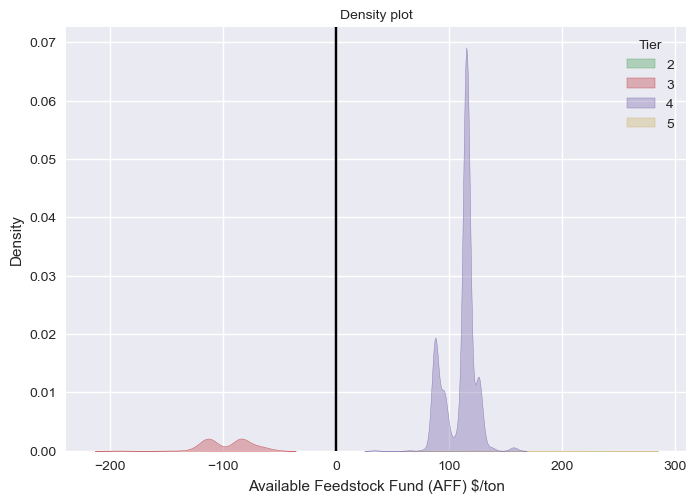

In [18]:
#  Using the final results df

df = pd.read_csv('results/combined-scenario-results.csv')
with sns.axes_style("darkgrid"):
    ax = sns.kdeplot(df,x='Ft_PerTonRes', hue='Tier' ,fill=True, alpha=0.4, palette=palette)
    ax.axvline(0, c='black', ls='-')
    # ax.axhline(0, c='black', ls='--')

plt.title('Density plot', fontsize=10)
ax.set(xlabel='Available Feedstock Fund (AFF) $/ton')
plt.show()




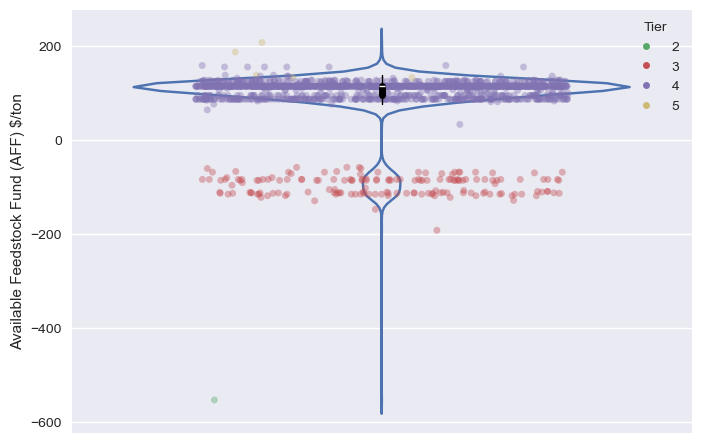

In [19]:
# Box Plot
df = pd.read_csv('results/combined-scenario-results.csv')

plt.style.use('seaborn')

palette ={1: "C5", 2: "C1", 3: "C2", 4: "C3", 5: "C4"}

# Create jittered version of "x" (which is only 0, 1, and 2)
#https://python-graph-gallery.com/web-ggbetweenstats-with-matplotlib/


df["all"] = ""
# ax = sns.violinplot(data=df[df.Tier == 1], y='Ft_PerTonRes',inner_kws=dict(box_width=5, whis_width=1, color="black"), alpha=0.4)
# ax = sns.violinplot(data=df[df.Tier == 2], y='Ft_PerTonRes',inner_kws=dict(box_width=5, whis_width=1, color="black"),alpha=0.4)
# ax = sns.violinplot(data=df[df.Tier == 3], y='Ft_PerTonRes',inner_kws=dict(box_width=5, whis_width=1, color="black"), alpha=0.4)
# ax = sns.violinplot(data=df[df.Tier == 4], y='Ft_PerTonRes',inner_kws=dict(box_width=5, whis_width=1, color="black"), alpha=0.4)
# ax = sns.violinplot(data=df[df.Tier == 5], y='Ft_PerTonRes',inner_kws=dict(box_width=5, whis_width=1, color="black"), alpha=0.4)

ax = sns.violinplot(data=df, y='Ft_PerTonRes',
                    inner_kws=dict(box_width=5, whis_width=1, color="black"), fill=False, native_scale=True)
ax.set_xlabel("")
ax.set_ylabel("Available Feedstock Fund (AFF) $/ton")
ax = sns.stripplot(y='Ft_PerTonRes', hue='Tier', data=df, 
                   zorder=1,
                jitter=0.3,alpha=0.4,palette=palette)

handles, labels = ax.get_legend_handles_labels()
leg = ax.legend(handles, labels, loc='upper right', title='Tier',framealpha=0.9)

for handle in leg.legendHandles:
            handle.set_alpha(1.0)

plt.show()

## Fine tuning Minimum LCOE value for each Tiers

<AxesSubplot:xlabel='Pop2030', ylabel='MinimumOverallLCOE2030'>

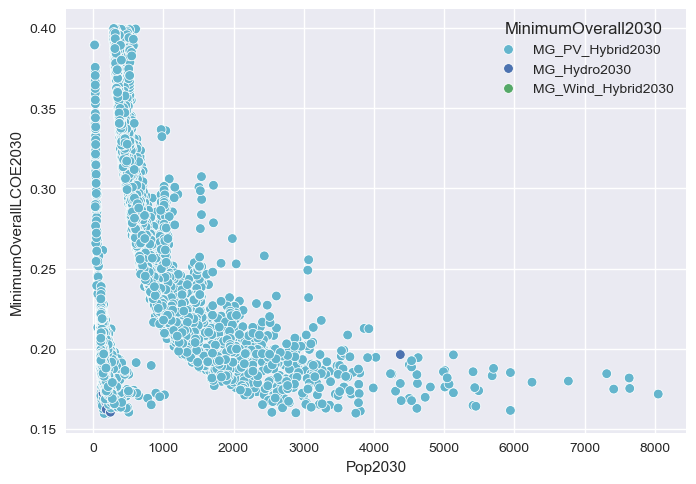

In [501]:
df = pd.read_csv('final-results1.csv')

plt.style.use('seaborn')

palette2 ={'MG_PV_Hybrid2030': "C5", 'MG_Hydro2030': "C6", "MG_Wind_Hybrid2030": "C7"}
    
sns.scatterplot(x='Pop2030',y='MinimumOverallLCOE2030', hue = 'MinimumOverall2030',data=df[(df.Ft_PerTonRes > 0) & (df.MinimumOverallLCOE2030 < 0.4) & (df.Tier == 4)], palette=palette2)

Bio-electrification systems in most cases was not suitable for replacing mini-grid hydro systems in clusters where the least cost technology was hydropower mini-grid (Even when Tier of access is level 4).

## Checking for population effect (what population is optimal for bioenergy???)


<AxesSubplot:xlabel='Pop2030', ylabel='Ft_PerTonRes'>

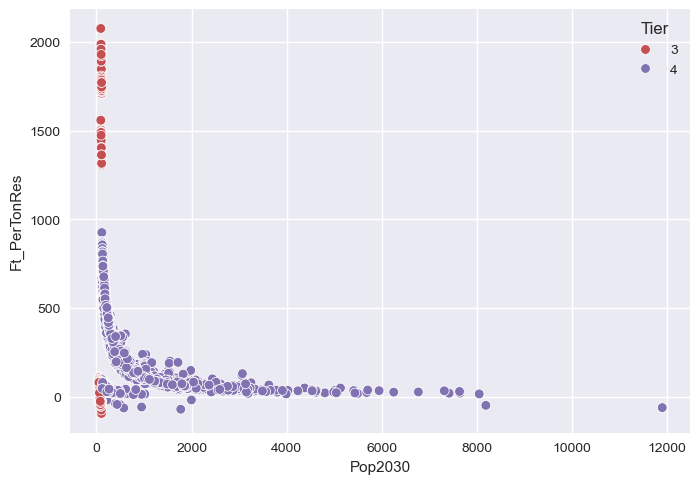

In [ ]:
## HDSCU scenario

df_test = df[df.scenario == '2_0_0_0_1_0']
palette ={1: "C5", 2: "C1", 3: "C2", 4: "C3", 5: "C4"}
sns.scatterplot(x='Pop2030',y='Ft_PerTonRes', hue = 'Tier',data=df_test, palette=palette)

# Notice!

The clusters below zero at a population less than 8000 are some Tier 3's and very little Tier 4's.


<AxesSubplot:xlabel='Pop2030', ylabel='MinimumOverallLCOE2030'>

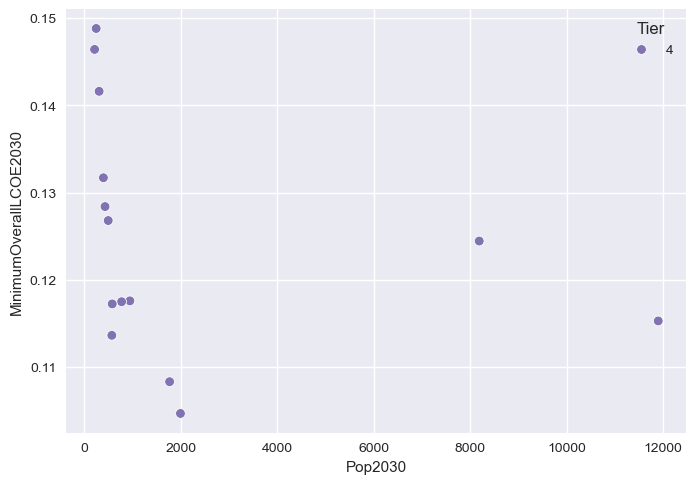

In [520]:
## Looking closer at the Feedstock prices below zero
# Added a different hue based on MinimumOverall2030 technology

df_test = df
palette ={1: "C5", 2: "C1", 3: "C2", 4: "C3", 5: "C4"}
sns.scatterplot(x='Pop2030',y='MinimumOverallLCOE2030', hue = 'Tier', data=df_test[(df_test.Ft_PerTonRes < 0) & (df_test.MinimumOverall2030 == 'MG_Hydro2030')], palette=palette)



<AxesSubplot:xlabel='Pop2030', ylabel='Ft_PerTonRes'>

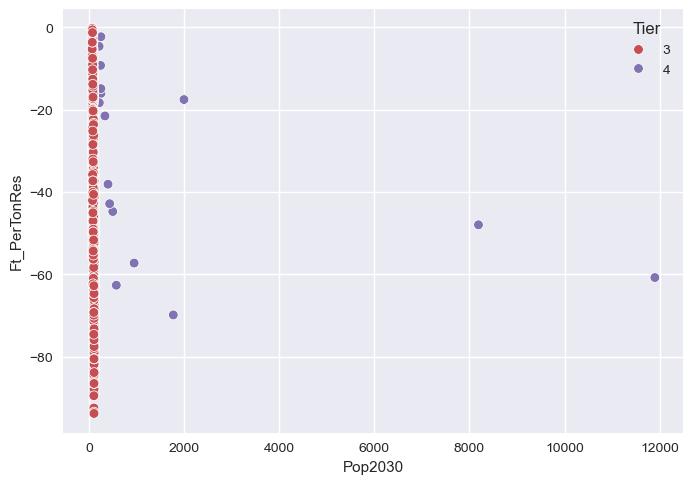

In [416]:
df_test = df[df.scenario == '2_0_0_0_1_0']
palette ={1: "C5", 2: "C1", 3: "C2", 4: "C3", 5: "C4"}
sns.scatterplot(x='Pop2030',y='Ft_PerTonRes', hue = 'Tier', data=df_test[df_test.Ft_PerTonRes < 0], palette=palette)


<AxesSubplot:xlabel='Pop2030', ylabel='Ft_PerTonRes'>

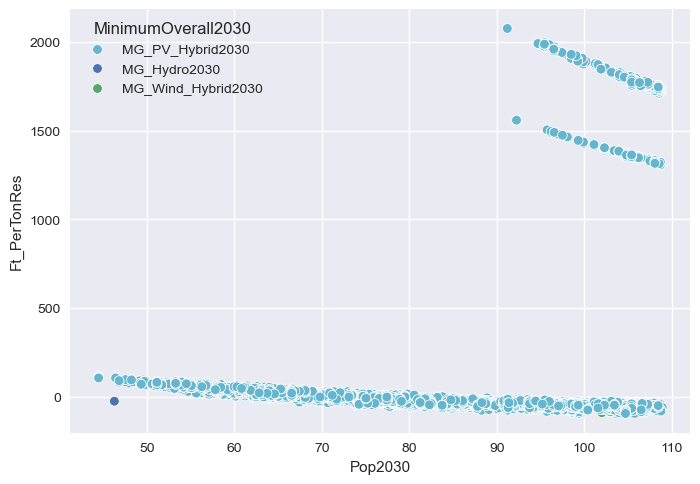

In [426]:
# considering only Tier 3 for the HDSCU scenario

df_test = df[df.scenario == '2_0_0_0_1_0']
palette ={1: "C5", 2: "C1", 3: "C2", 4: "C3", 5: "C4"}
sns.scatterplot(x='Pop2030',y='Ft_PerTonRes', hue = 'MinimumOverall2030', data=df_test[(df_test.Tier == 3)], palette=palette2)


<AxesSubplot:xlabel='Pop2030', ylabel='Ft_PerTonRes'>

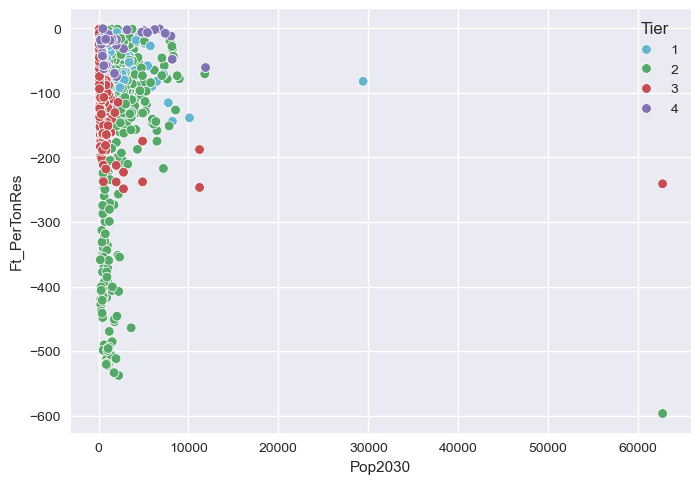

In [438]:
## Now we have tested this approach on one scenario, let us apply it to the remaining

## Looking closer at the Feedstock prices below zero
# Added a different hue based on MinimumOverall2030 technology

df_test = df[df.Ft_PerTonRes < 0]
palette ={1: "C5", 2: "C1", 3: "C2", 4: "C3", 5: "C4"}
sns.scatterplot(x='Pop2030',y='Ft_PerTonRes', hue = 'Tier', data=df_test, palette=palette)


<AxesSubplot:xlabel='Pop2030', ylabel='Ft_PerTonRes'>

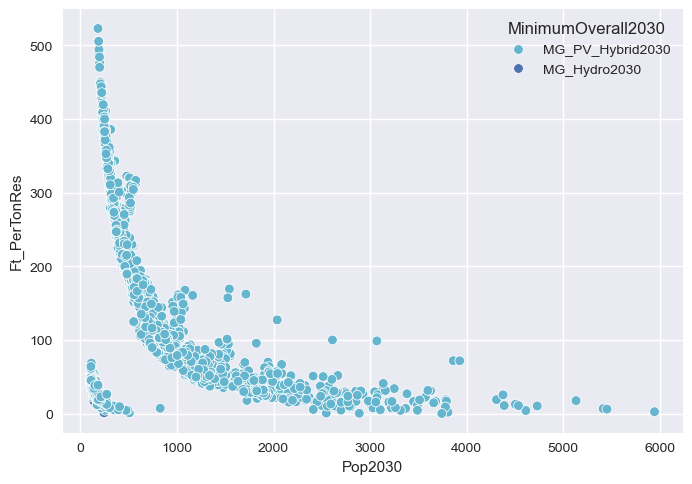

In [525]:
## Isolating individual Tiers and using limit on LCOE for different Tiers to understand population limit

df_test = df[df.Ft_PerTonRes > 0]
palette ={1: "C5", 2: "C1", 3: "C2", 4: "C3", 5: "C4"}
sns.scatterplot(x='Pop2030',y='Ft_PerTonRes', hue = 'MinimumOverall2030', data=df_test[(df_test.Tier == 4)], palette=palette2)




In [21]:
print(plt.style.available)

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'seaborn', 'seaborn-bright', 'seaborn-colorblind', 'seaborn-dark', 'seaborn-dark-palette', 'seaborn-darkgrid', 'seaborn-deep', 'seaborn-muted', 'seaborn-notebook', 'seaborn-paper', 'seaborn-pastel', 'seaborn-poster', 'seaborn-talk', 'seaborn-ticks', 'seaborn-white', 'seaborn-whitegrid', 'tableau-colorblind10']


ng-3-0_0_0_0_1_0-results
ng-3-0_0_0_1_1_0-results
ng-3-0_1_0_0_1_0-results
ng-3-0_1_0_1_1_0-results
ng-3-2_0_0_0_1_0-results
ng-3-2_0_0_1_1_0-results


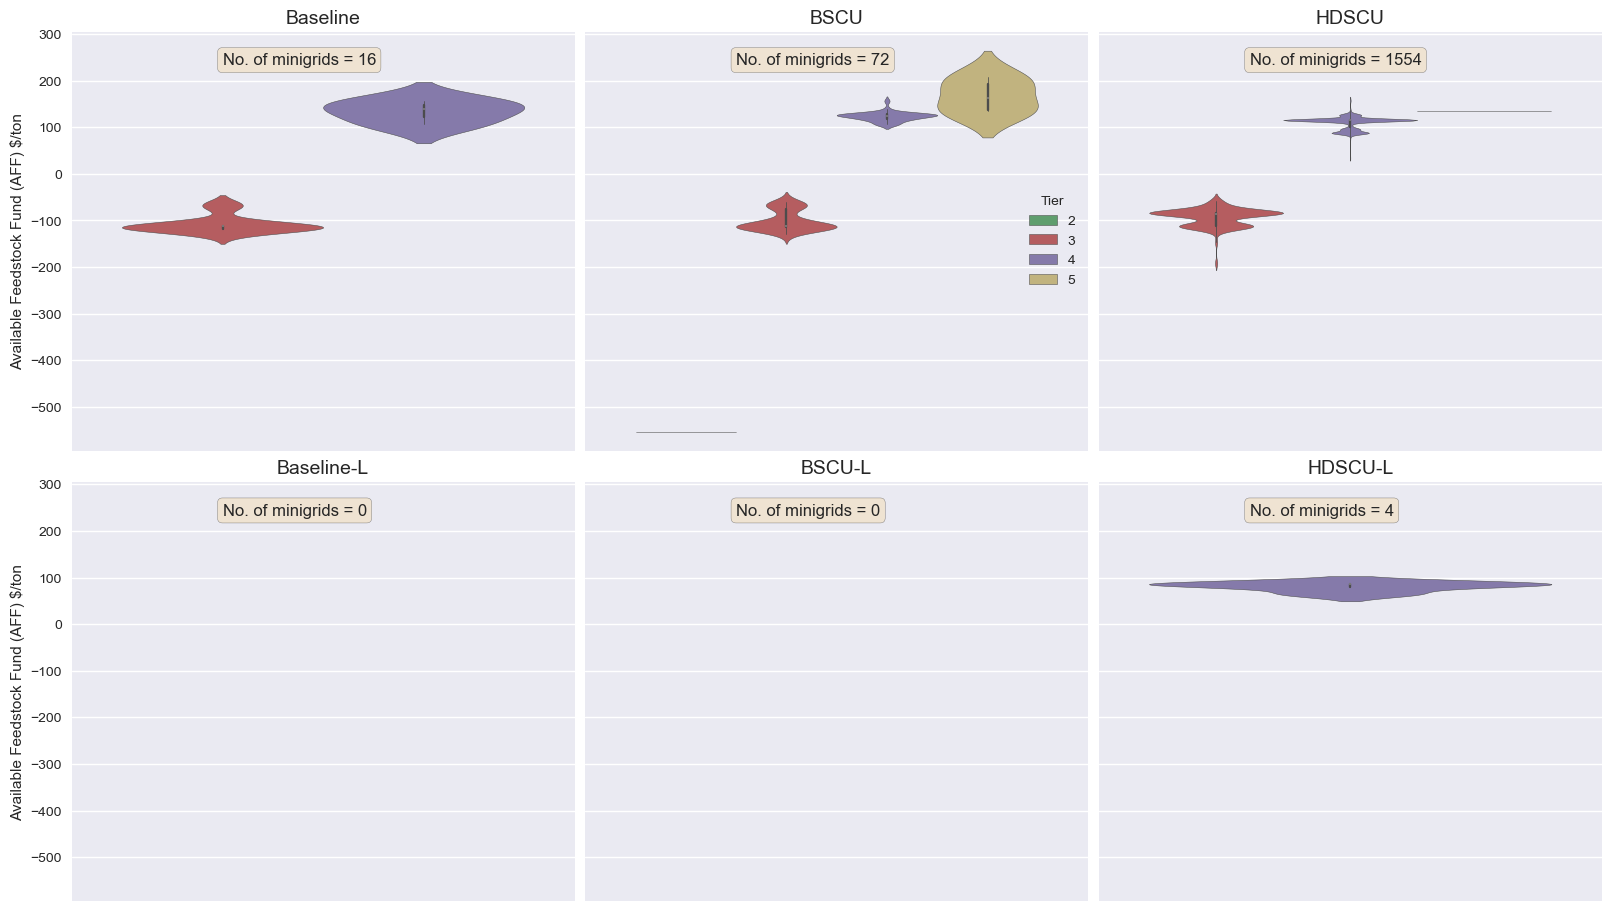

In [20]:
path=os.getcwd()+ '/results/scenarios'

import matplotlib.ticker as ticker
plt.style.use('seaborn')
figure, axis = plt.subplots(2, 3, figsize=(16,9),layout='constrained', sharey=True)

palette ={1: "C5", 2: "C1", 3: "C2", 4: "C3", 5: "C4"}

for scenario_file in sorted(os.listdir(path)):
    
    if scenario_file.endswith(".csv"):
        
        scenario = scenario_file.split('.')[0]
        
        file = path + f'/{scenario_file}'
        df = pd.read_csv(file)
        
        textstr = f'No. of minigrids = {len(df)}'
        props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
        print(scenario)     
        
        if scenario == 'ng-3-0_1_0_0_1_0-results':
            sns.violinplot(data=df, y='Ft_PerTonRes', hue='Tier',ax = axis[0,0],palette=palette, legend=None)
            #df.boxplot(column = 'Ft_PerTonRes', by = 'Tier', ax = axis[counter,0])
            axis[0,0].text(0.3, 0.95, textstr, transform=axis[0,0].transAxes, fontsize=12, verticalalignment='top', bbox=props)
            axis[0,0].set_title('Baseline', fontsize=14)
            axis[0,0].set(xlabel=None)
            
            
        elif scenario == 'ng-3-0_1_0_1_1_0-results':
            sns.violinplot(data=df, y='Ft_PerTonRes', hue='Tier',ax = axis[1,0],palette=palette, legend=None)
            #df.boxplot(column = 'Ft_PerTonRes', by = 'Tier', ax = axis[counter,0])
            axis[1,0].text(0.3, 0.95, textstr, transform=axis[1,0].transAxes, fontsize=12, verticalalignment='top', bbox=props)
            axis[1,0].set_title('Baseline-L', fontsize=14)
            axis[1,0].xaxis.grid(False)
            axis[1,0].xaxis.set_major_locator(ticker.NullLocator())
        
        elif scenario == 'ng-3-0_0_0_0_1_0-results':
            sns.violinplot(data=df, y='Ft_PerTonRes', hue='Tier',ax = axis[0,1],palette=palette)
            #df.boxplot(column = 'Ft_PerTonRes', by = 'Tier', ax = axis[counter,0])
            axis[0,1].text(0.3, 0.95, textstr, transform=axis[0,1].transAxes, fontsize=12, verticalalignment='top', bbox=props)
            axis[0,1].set_title('BSCU', fontsize=14)
            axis[0,1].set(xlabel=None)
            
        elif scenario == 'ng-3-0_0_0_1_1_0-results':
            sns.violinplot(data=df, y='Ft_PerTonRes', hue='Tier',ax = axis[1,1],palette=palette)
            #df.boxplot(column = 'Ft_PerTonRes', by = 'Tier', ax = axis[counter,0])
            axis[1,1].text(0.3, 0.95, textstr, transform=axis[1,1].transAxes, fontsize=12, verticalalignment='top', bbox=props)
            axis[1,1].set_title('BSCU-L', fontsize=14)
            axis[1,1].xaxis.grid(False)
            axis[1,1].xaxis.set_major_locator(ticker.NullLocator())

            
        elif scenario == 'ng-3-2_0_0_0_1_0-results':
            sns.violinplot(data=df, y='Ft_PerTonRes', hue='Tier',ax = axis[0,2],palette=palette,legend=None)
            #df.boxplot(column = 'Ft_PerTonRes', by = 'Tier', ax = axis[counter,0])
            axis[0,2].text(0.3, 0.95, textstr, transform=axis[0,2].transAxes, fontsize=12, verticalalignment='top', bbox=props)
            axis[0,2].set_title('HDSCU', fontsize=14)
            axis[0,2].set(xlabel=None)
            
        elif scenario == 'ng-3-2_0_0_1_1_0-results':
            sns.violinplot(data=df, y='Ft_PerTonRes', hue='Tier',ax = axis[1,2],palette=palette,legend=None)
            #df.boxplot(column = 'Ft_PerTonRes', by = 'Tier', ax = axis[counter,0])
            axis[1,2].text(0.3, 0.95, textstr, transform=axis[1,2].transAxes, fontsize=12, verticalalignment='top', bbox=props)
            axis[1,2].set_title('HDSCU-L', fontsize=14)
sns.despine()


handles1, labels1 = axis[0,1].get_legend_handles_labels()

axis[0,1].legend(handles1, labels1, loc='center right', title='Tier')


plt.setp(axis[:, 0], ylabel='Available Feedstock Fund (AFF) $/ton')
plt.show()




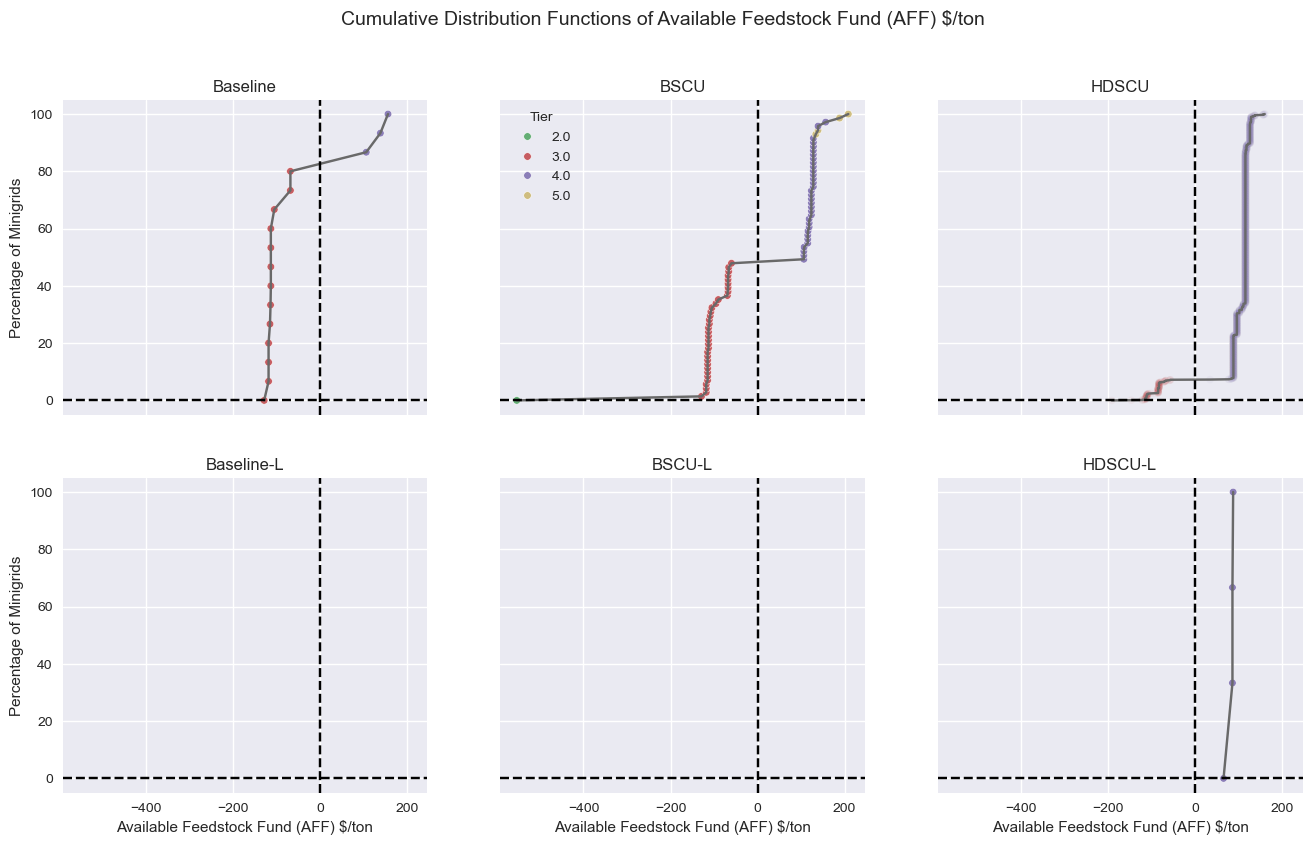

In [21]:
plt.style.use('seaborn')
plt.rcParams['figure.figsize'] = [12, 10]
plt.rcParams['figure.dpi'] = 100
palette ={1: "C5", 2: "C1", 3: "C2", 4: "C3", 5: "C4"}

df = pd.read_csv('results/CDF.csv')
cdfCol = df.columns
figure, axis = plt.subplots(2, 3, figsize=(16,9),sharey=True, sharex=True)


textstr = f'No. of minigrids = 72'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)

sns.lineplot(data=df, x='ng-3-0_0_0_0_1_0',y='ng-3-0_0_0_0_1_0-cum', ax= axis[0,1], color='dimgrey')
sns.scatterplot(data=df, x='ng-3-0_0_0_0_1_0', y='ng-3-0_0_0_0_1_0-cum', s=30, alpha=0.9, hue='ng-3-0_0_0_0_1_0-tier', ax=axis[0,1], palette=palette)
axis[0,1].set(title='BSCU')
axis[0,1].axvline(0, c='black', ls='--') 
axis[0,1].axhline(0, c='black', ls='--')
axis[0,1].get_legend().set_visible(True)
axis[0,1].legend(title='Tier')
axis[0,1].set(xlabel=None)
# axis[0,1].text(0.3, 0.5, textstr, transform=axis[0,1].transAxes, fontsize=10, verticalalignment='center', bbox=props)


textstr = f'No. of minigrids = 0'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)

sns.lineplot(data=df, x='ng-3-0_0_0_1_1_0',y='ng-3-0_0_0_1_1_0-cum', ax= axis[1,1], color='dimgrey')
sns.scatterplot(data=df, x='ng-3-0_0_0_1_1_0', y='ng-3-0_0_0_1_1_0-cum', s=30, alpha=0.9, hue='ng-3-0_0_0_1_1_0-tier', ax=axis[1,1])
axis[1,1].set(title='BSCU-L')
axis[1,1].axvline(0, c='black', ls='--') 
axis[1,1].axhline(0, c='black', ls='--') 
axis[1,1].set(xlabel=None)
# axis[1,1].text(0.3, 0.5, textstr, transform=axis[1,1].transAxes, fontsize=10, verticalalignment='center', bbox=props)

textstr = f'No. of minigrids = 16'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)

sns.lineplot(data=df, x='ng-3-0_1_0_0_1_0',y='ng-3-0_1_0_0_1_0-cum', ax= axis[0,0], color='dimgrey')
sns.scatterplot(data=df, x='ng-3-0_1_0_0_1_0', y='ng-3-0_1_0_0_1_0-cum', s=30, alpha=0.9, hue='ng-3-0_1_0_0_1_0-tier', ax=axis[0,0],palette=palette)
axis[0,0].set(title='Baseline')
axis[0,0].axvline(0, c='black', ls='--') 
axis[0,0].axhline(0, c='black', ls='--')
axis[0,0].get_legend().set_visible(False)
axis[0,0].set(xlabel=None)
# axis[0,0].text(0.3, 0.5, textstr, transform=axis[0,0].transAxes, fontsize=10, verticalalignment='center', bbox=props)


textstr = f'No. of minigrids = 0'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)

sns.lineplot(data=df, x='ng-3-0_1_0_1_1_0', y='ng-3-0_1_0_1_1_0-cum', ax= axis[1,0], color='white')
sns.scatterplot(data=df, x='ng-3-0_1_0_1_1_0', y='ng-3-0_1_0_1_1_0-cum', s=30, alpha=0.9, hue='ng-3-0_1_0_1_1_0-tier', ax=axis[1,0])
axis[1,0].set(title='Baseline-L')
axis[1,0].axvline(0, c='black', ls='--') 
axis[1,0].axhline(0, c='black', ls='--')
axis[1,0].set(xlabel=None)
# axis[1,0].text(0.3, 0.5, textstr, transform=axis[1,0].transAxes, fontsize=10, verticalalignment='center', bbox=props)

textstr = f'No. of minigrids = 1554'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)

sns.lineplot(data=df, x='ng-3-2_0_0_0_1_0',y='ng-3-2_0_0_0_1_0-cum', ax= axis[0,2], color='dimgrey')
sns.scatterplot(data=df, x='ng-3-2_0_0_0_1_0', y='ng-3-2_0_0_0_1_0-cum', s=30, alpha=0.05, hue='ng-3-2_0_0_0_1_0-tier', ax=axis[0,2],palette=palette, legend=None)
axis[0,2].set(title='HDSCU')
axis[0,2].axvline(0, c='black', ls='--') 
axis[0,2].axhline(0, c='black', ls='--')
axis[0,2].set(xlabel=None)
# axis[0,2].text(0.3, 0.5, textstr, transform=axis[0,2].transAxes, fontsize=10, verticalalignment='center', bbox=props)

textstr = f'No. of minigrids = 4'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)

sns.lineplot(data=df, x='ng-3-2_0_0_1_1_0',y='ng-3-2_0_0_1_1_0-cum', ax= axis[1,2], color='dimgrey')
sns.scatterplot(data=df, x='ng-3-2_0_0_1_1_0', y='ng-3-2_0_0_1_1_0-cum', s=30, alpha=0.9, hue='ng-3-2_0_0_1_1_0-tier', ax=axis[1,2],palette=palette,legend=None)
axis[1,2].set(title='HDSCU-L')
axis[1,2].axvline(0, c='black', ls='--') 
axis[1,2].axhline(0, c='black', ls='--')
axis[1,2].set(xlabel=None)
# axis[1,2].text(0.3, 0.5, textstr, transform=axis[1,2].transAxes, fontsize=10, verticalalignment='center', bbox=props)

    
figure.suptitle('Cumulative Distribution Functions of Available Feedstock Fund (AFF) $/ton', fontsize=14)
#figure.supxlabel('Ft_PerTonRes', fontsize= 14)
#figure.supylabel('Percentage of Minigrids', fontsize=14)




sns.despine()
plt.setp(axis[-1, :], xlabel='Available Feedstock Fund (AFF) $/ton')
plt.setp(axis[:, 0], ylabel='Percentage of Minigrids')
plt.show()

## Understanding investment requirements


In [26]:
path=os.getcwd()+ '/results/scenarios'
investments = []
scenarios = []
techLabel = ["MG", "Bio"]

for scenario_file in sorted(os.listdir(path)):
    
    if scenario_file.endswith(".csv"):
        
        scenario = scenario_file.split('-')[2]
        
        file = path + f'/{scenario_file}'
        df = pd.read_csv(file)
        
        df = df[df.Ft_PerTonRes > 0].reset_index()
        
        total_MG_investment = (df.Generation_Capex2030.sum() + df.Generation_Capex2025.sum())/1000000  #in Millions of dollars
        total_Bio_investment = df.investment.sum()/1000000
        
        print(f'total_Bio_investment: {total_Bio_investment}')
        print(f'total_MG_investment: {total_MG_investment}')
        
        scenarios.extend([scenario, scenario])
        investments.extend([total_MG_investment, total_Bio_investment])
        



total_Bio_investment: 1.146303390260646
total_MG_investment: 1.189359768
total_Bio_investment: 0.0
total_MG_investment: 0.0
total_Bio_investment: 0.07588443147705479
total_MG_investment: 0.082442032
total_Bio_investment: 0.0
total_MG_investment: 0.0
total_Bio_investment: 386.4445634401143
total_MG_investment: 447.4110900293
total_Bio_investment: 1.9089574339212327
total_MG_investment: 1.2426867819999998


In [27]:
df_invest = pd.DataFrame({
    "scenario":scenarios,
    "investments": investments,
    "tech": np.tile(techLabel, 6)# three scenarios
})

In [28]:
df_invest

,scenario,investments,tech
0,0_0_0_0_1_0,1.189360,MG
1,0_0_0_0_1_0,1.146303,Bio
2,0_0_0_1_1_0,0.000000,MG
3,0_0_0_1_1_0,0.000000,Bio
4,0_1_0_0_1_0,0.082442,MG
5,0_1_0_0_1_0,0.075884,Bio
6,0_1_0_1_1_0,0.000000,MG
7,0_1_0_1_1_0,0.000000,Bio
8,2_0_0_0_1_0,447.411090,MG
9,2_0_0_0_1_0,386.444563,Bio


[Text(0, 0.5, 'Investments in millions of dollars ($)')]

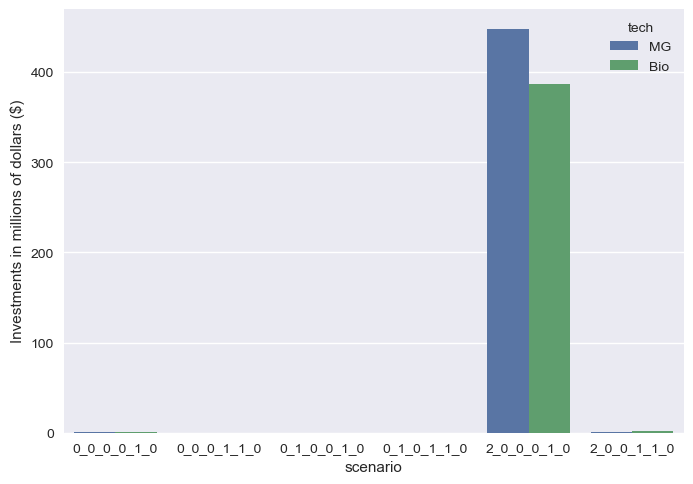

In [29]:
plt.style.use('seaborn')
ax = sns.barplot(x='scenario', y='investments', hue='tech', data=df_invest)
ax.set(ylabel='Investments in millions of dollars ($)')

In [30]:
df_invest_pivoted = df_invest.pivot(index=['tech'], columns='scenario', values='investments')
df_invest_pivoted['tech'] = ['Bio', 'MG']

In [31]:
df_invest_pivoted

scenario,0_0_0_0_1_0,0_0_0_1_1_0,0_1_0_0_1_0,0_1_0_1_1_0,2_0_0_0_1_0,2_0_0_1_1_0,tech
tech,,,,,,,
Bio,1.146303,0.0,0.075884,0.0,386.444563,1.908957,Bio
MG,1.189360,0.0,0.082442,0.0,447.411090,1.242687,MG


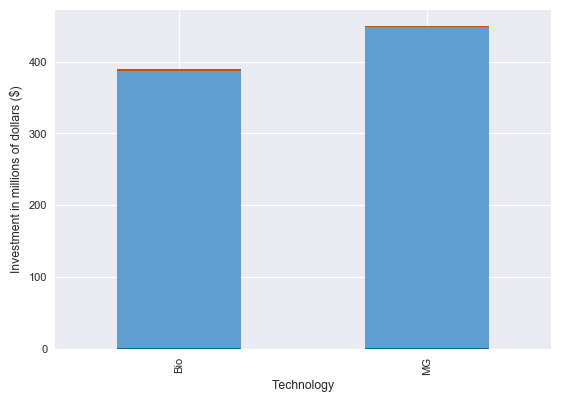

In [37]:
plt.style.use('tableau-colorblind10')
df_invest_pivoted.plot(x='tech', kind='bar', stacked=True, legend=False)
plt.xlabel("Technology")
plt.ylabel("Investment in millions of dollars ($)")
plt.show()

In [38]:
file=os.getcwd()+ '/results/combined-scenario-results.csv'
df = pd.read_csv(file)

In [39]:
df1 = df[(df.Ft_PerTonRes > 0)]

In [40]:
print(f"Total number of mini-grids: {len(df)}")
print(f"Number of mini-grids with AFF above zero: {len(df1)}")
print(f"Maximum AFF: {df.Ft_PerTonRes.max()}")
print(f"Maximum Gasifier capacity in (KW): {df.GasifierCap.max()}")

Total number of mini-grids: 1646
Number of mini-grids with AFF above zero: 1485
Maximum AFF: 208.32631458415307
Maximum Gasifier capacity in (KW): 1225.2805365296804


In [41]:
df.Ft_PerTonRes.min()

-553.2735994964586

## Understanding gasifier capacity, investment, and AFF

<AxesSubplot:xlabel='Ft_PerTonRes', ylabel='GasifierCap'>

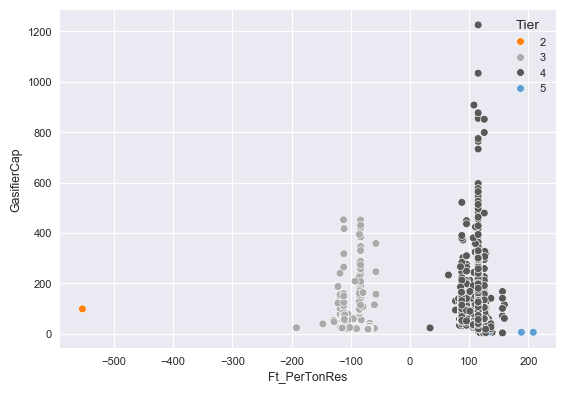

In [42]:
 sns.scatterplot(data=df, y="GasifierCap" ,x='Ft_PerTonRes', hue="Tier",  palette=palette)

<AxesSubplot:xlabel='TotalEnergyPerCell', ylabel='GasifierCap'>

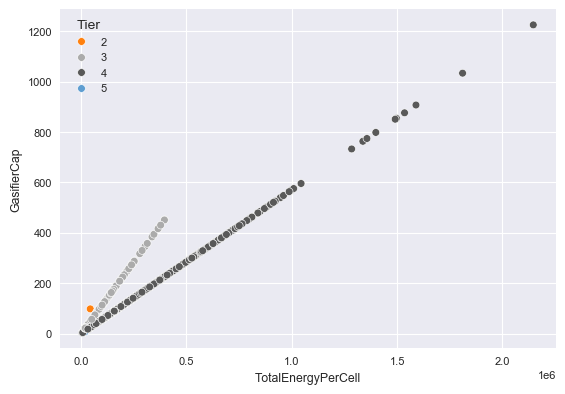

In [43]:
 sns.scatterplot(data=df, y="GasifierCap" ,x='TotalEnergyPerCell', hue="Tier",  palette=palette)

<AxesSubplot:xlabel='MinimumOverallLCOE2030', ylabel='Generation_Capex2030'>

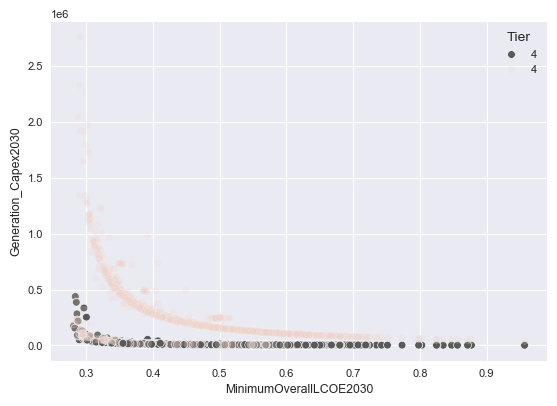

In [44]:
sns.scatterplot(data=df[df.Tier == 4], y="Generation_Capex2030" ,x='MinimumOverallLCOE2030', hue="Tier", palette=palette)
sns.scatterplot(data=df[df.Tier == 4], y="investment" ,x='MinimumOverallLCOE2030', hue="Tier", alpha=0.2)


## HDSCU plots

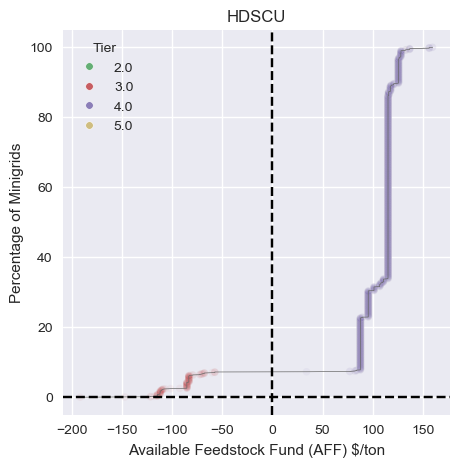

In [45]:
plt.style.use('seaborn')
plt.rcParams['figure.figsize'] = [5, 5]
plt.rcParams['figure.dpi'] = 100
palette ={1: "C5", 2: "C1", 3: "C2", 4: "C3", 5: "C4"}

df = pd.read_csv('results/CDF.csv')
cdfCol = df.columns


textstr = f'No. of minigrids = 72'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)

sns.lineplot(data=df, x='ng-3-2_0_0_0_1_0',y='ng-3-2_0_0_0_1_0-cum', color='dimgrey', linewidth=0.5)
ax = sns.scatterplot(data=df, x='ng-3-2_0_0_0_1_0', y='ng-3-2_0_0_0_1_0-cum', s=30, alpha=0.06, hue='ng-3-2_0_0_0_1_0-tier',palette=palette, )
ax.set(title='HDSCU')
ax.axvline(0, c='black', ls='--') 
ax.axhline(0, c='black', ls='--')
ax.set(xlabel=None)
ax.legend(title='Tier')

handles1, labels1 = axis[0,1].get_legend_handles_labels()
leg = ax.legend(handles1, labels1, loc='upper left', title='Tier',framealpha=1.0)


# for handle in leg.legend_handles:
#             handle.set_alpha(1.0)

plt.setp(ax, xlabel='Available Feedstock Fund (AFF) $/ton')
plt.setp(ax, ylabel='Percentage of Minigrids')
plt.show()

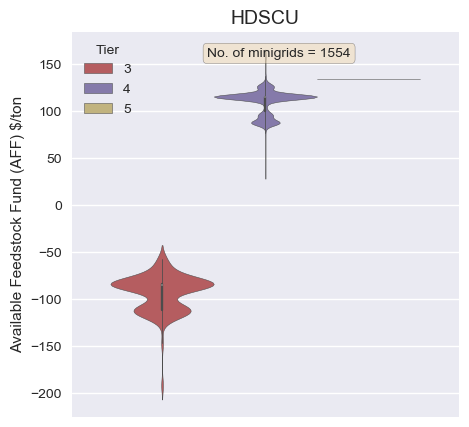

In [46]:
file=os.getcwd()+ '/results/scenarios/ng-3-2_0_0_0_1_0-results.csv'
df = pd.read_csv(file)

plt.style.use('seaborn')
plt.rcParams['figure.figsize'] = [5, 5]
plt.rcParams['figure.dpi'] = 100

textstr = f'No. of minigrids = {len(df)}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)

ax = sns.violinplot(data=df, y='Ft_PerTonRes', hue='Tier',palette=palette)
ax.text(0.35, 0.96, textstr, transform=ax.transAxes, fontsize=10, verticalalignment='top', bbox=props)
ax.set_title('HDSCU', fontsize=14)
ax.set(xlabel=None)

plt.setp(ax, ylabel='Available Feedstock Fund (AFF) $/ton')
plt.show()